In [59]:
import random
import torch
import numpy as np
from scipy.io import loadmat
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


In [60]:
import os
from PIL import Image
import numpy as np
from torchvision.transforms import ToTensor
from torch.utils.data import Dataset


class DriveDataset(Dataset):
    def __init__(self, root: str, train: bool, transforms=None,pi_transforms=None):
        super(DriveDataset, self).__init__()
        self.flag = "training" if train else "test"
        self.train = train
        data_root = os.path.join(root, "DRIVE", self.flag)
        assert os.path.exists(data_root), f"path '{data_root}' does not exist."
        
        self.transforms = transforms  # Transforms for img only
        self.pi_transforms = pi_transforms  # Transforms for PI only
        
        
        img_names = [i for i in os.listdir(os.path.join(data_root, "images")) if i.endswith(".tif")]
        self.img_list = [os.path.join(data_root, "images", i) for i in img_names]
        self.pi_list = [os.path.join(data_root, 'PI', i.split(".")[0] + '_PI.mat') for i in img_names]

        # Check for missing files
        for pi_path in self.pi_list:
            if not os.path.exists(pi_path):
                raise FileNotFoundError(f"file {pi_path} does not exist.")

    def __getitem__(self, idx):
        # Load the RGB image (input)
        img = Image.open(self.img_list[idx]).convert('RGB')
        # Load the persistence image (PI, ground truth)
        PI_data = loadmat(self.pi_list[idx])
        PI = PI_data['image']
        PI[PI < 0] = 0
        PI[PI > 1] = 1
        # PI = torch.tensor(PI, dtype=torch.float32)

        # Apply the transforms to img only, not PI
        if self.transforms is not None:
            img = self.transforms(img)  # Apply to img only
        #PI = PI * 255.0  # Normalize PI to [0, 1]
        return img, PI

    def __len__(self):
        return len(self.img_list)

    @staticmethod
    def collate_fn(batch):
        images, pi = list(zip(*batch))  # Unpack into images and PI
        batched_imgs = cat_list(images, fill_value=0)
        batched_pi = cat_list(pi, fill_value=0)
        return batched_imgs, batched_pi


def cat_list(images, fill_value=0):
    max_size = tuple(max(s) for s in zip(*[img.shape for img in images]))
    batch_shape = (len(images),) + max_size
    batched_imgs = images[0].new(*batch_shape).fill_(fill_value)
    for img, pad_img in zip(images, batched_imgs):
        pad_img[..., :img.shape[-2], :img.shape[-1]].copy_(img)
    return batched_imgs

In [ ]:
import os
import torch
from torch.utils.data import DataLoader
from torchvision import transforms

# Define the mean and standard deviation (using common ImageNet stats or those computed from your dataset)
mean = [0.485, 0.456, 0.406]  # Mean values for RGB images
std = [0.229, 0.224, 0.225]   # Standard deviations for RGB images

# Define data augmentation transforms for PI (without normalization)
pi_train_transforms = transforms.Compose([
    transforms.Resize((500, 500)),           # Resize to a uniform size
    transforms.RandomHorizontalFlip(),         # Random horizontal flip
    transforms.RandomRotation(15),             # Random rotation up to 15 degrees
    transforms.ToTensor(),                     # Convert image to PyTorch tensor
])

pi_test_transforms = transforms.Compose([
    transforms.Resize((500, 500)),           # Resize to a uniform size
    transforms.ToTensor(),                     # Convert image to PyTorch tensor
])

# Define training transforms (including data augmentation and normalization)
train_transforms = transforms.Compose([
    transforms.Resize((500, 500)),           # Resize to a uniform size
    transforms.RandomHorizontalFlip(),         # Random horizontal flip
    transforms.RandomRotation(15),             # Random rotation up to 15 degrees
    transforms.ToTensor(),                     # Convert image to PyTorch tensor
    transforms.Normalize(mean=mean, std=std),   # Normalize the image
])

# Define testing transforms (only resizing, conversion, and normalization)
test_transforms = transforms.Compose([
    transforms.Resize((500, 500)),           # Resize to a uniform size
    transforms.ToTensor(),                     # Convert image to PyTorch tensor
    transforms.Normalize(mean=mean, std=std),   # Normalize the image
])

# Here is the implementation of the DriveDataset class (not shown)

data_path = r'./'
batch_size = 5

# Create training and validation datasets
train_dataset = DriveDataset(data_path,
                             train=True,
                             transforms=train_transforms,
                             pi_transforms=pi_train_transforms)  # Training dataset

val_dataset = DriveDataset(data_path,
                           train=False,
                           transforms=test_transforms,
                           pi_transforms=pi_test_transforms)  # Validation dataset

# Set the number of worker threads: minimum of available CPU cores, batch_size (if >1), and 8
num_workers = min([os.cpu_count(), batch_size if batch_size > 1 else 0, 8])

# Create DataLoaders for training and validation datasets
train_loader = DataLoader(train_dataset,
                          batch_size=batch_size,
                          num_workers=num_workers,
                          shuffle=True,
                          pin_memory=True)

val_loader = DataLoader(val_dataset,
                        batch_size=1,
                        num_workers=num_workers,
                        pin_memory=True)


In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Image_PINet(nn.Module):
    def __init__(self):
        super(Image_PINet, self).__init__()
        
        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 128, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(128)
        
        self.conv2 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(256)
        
        self.conv3 = nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(512)
        
        self.conv4 = nn.Conv2d(512, 1024, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(1024)
        
        # Pooling
        self.pool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        # Global average pooling
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Fully connected layer
        self.fc = nn.Linear(1024, 2500)
        
        self.deconv1 = nn.ConvTranspose2d(
    in_channels=1,
    out_channels=256,
    kernel_size=3,
    stride=2,
    padding=1,
    output_padding=1  # Ensure the output size matches the target size
)
        self.bn_deconv1 = nn.BatchNorm2d(256)

        self.deconv2 = nn.ConvTranspose2d(
    in_channels=256,
    out_channels=128,
    kernel_size=3,
    stride=2,
    padding=1,
    output_padding=1  # Ensure the output size matches the target size
)
        self.bn_deconv2 = nn.BatchNorm2d(128)

        self.deconv3 = nn.ConvTranspose2d(
    in_channels=128,
    out_channels=64,
    kernel_size=3,
    stride=2,
    padding=1,
    output_padding=1  # Ensure the output size matches the target size
)
        self.bn_deconv3 = nn.BatchNorm2d(64)

        self.deconv4 = nn.ConvTranspose2d(
    in_channels=64,
    out_channels=3,
    kernel_size=3,
    stride=2,
    padding=1,
    output_padding=1  # Ensure the output size matches the target size
)
        self.bn_deconv4 = nn.BatchNorm2d(3)
        self.conv1x1 = nn.Conv2d(3, 3, kernel_size=1, stride=1, padding=0)  # Mapping 3 channels to 3 channels

    def forward(self, x):
        # Initial input shape: (b, 3, 500, 500)
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # (b, 128, 250, 250)
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # (b, 256, 125, 125)
        x = self.pool(F.relu(self.bn3(self.conv3(x))))  # (b, 512, 63, 63)
        x = F.relu(self.bn4(self.conv4(x)))             # (b, 1024, 63, 63)
    
        # Global average pooling
        x = self.global_pool(x)                         # (b, 1024, 1, 1)
        x = torch.flatten(x, 1)                         # (b, 1024)
    
        # Fully connected layer
        x = F.relu(self.fc(x))                          # (b, 2500)
    
        # Reshape to (b, 1, 50, 50)
        x = x.view(-1, 1, 50, 50)
        
    
        # 逐步反卷积，逐步恢复图像
        x = F.relu(self.bn_deconv1(self.deconv1(x)))    # (b, 256, 100, 100)
        
        x = F.relu(self.bn_deconv2(self.deconv2(x)))    # (b, 128, 200, 200)
        
        x = F.relu(self.bn_deconv3(self.deconv3(x)))    # (b, 64, 400, 400)
        
        x = F.relu(self.bn_deconv4(self.deconv4(x)))    # (b, 3, 800, 800)
        
        x = F.interpolate(x, size=(500, 500), mode='bicubic', align_corners=False)
        x = self.conv1x1(x)  # (b, 3, 500, 500)
        # Sigmoid activation function, ensure output is in range [0, 1]
        output = torch.sigmoid(x)  # (b, 4, 500, 500)
        # Add a V channel manually (255 for max value)
       
        v_channel = torch.ones(x.size(0), 1, 500, 500, device=x.device) 
        
        # Concatenate the V channel to the RGB output (only once)
        output = torch.cat((x, v_channel), dim=1)       # (b, 4, 500, 500)


        return output

In [ ]:
import torch.optim as optim
import torch
import torch.nn.functional as F
import torch.nn as nn
import os
import pytorch_ssim
import pandas as pd
import torch.nn.functional as F
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from scipy.stats import pearsonr

# Model hyperparameters
num_epochs = 500
learning_rate_initial = 1e-3
learning_rate_mid = 1e-4
learning_rate_final = 1e-5

def gradient_regularization(output):
    """Calculate gradient regularization term."""
    # Compute horizontal gradient (difference between adjacent rows)
    grad_x = torch.abs(output[:, :-1, :] - output[:, 1:, :])
    # Compute vertical gradient (difference between adjacent columns)
    grad_y = torch.abs(output[:, :, :-1] - output[:, :, 1:])
    return torch.mean(grad_x) + torch.mean(grad_y)

# Define the model and optimizer
model = Image_PINet()
optimizer = optim.Adam(model.parameters(), lr=learning_rate_initial)

# Move the model to GPU (if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Initialize variables to save the best model weights
best_mse = float('inf')
best_model_wts = None

# Create directory to save model weights (if not exists)
if not os.path.exists('./pi_weights'):
    os.makedirs('./pi_weights')

# Create a log file for training metrics
log_file_path = './pi_weights/training_log.csv'
log_columns = ['epoch', 'mse', 'ssim', 'pearson_corr', 'model_path']
if not os.path.exists(log_file_path):
    pd.DataFrame(columns=log_columns).to_csv(log_file_path, index=False)

# Training loop
for epoch in range(num_epochs):
    # Dynamically adjust learning rate
    if epoch < 100:
        lr = learning_rate_initial
    elif epoch < 300:
        lr = learning_rate_mid
    else:
        lr = learning_rate_final
    
    # Update the learning rate in the optimizer
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

    model.train()  # Set model to training mode
    running_loss = 0.0
    
    # Iterate over the training dataset
    for imgs, pi in tqdm(train_loader):
        imgs = imgs.to(device)  # Move input images to GPU
        pi = pi.to(device).float()  # Convert pi to float32 and move to GPU
        
        # Forward pass: generate persistence image
        output_pi = model(imgs)
        
        # Compute loss (MSE between output and target persistence image)
        loss = F.mse_loss(output_pi, pi)
        running_loss += loss.item()

        # Backward pass and optimization
        optimizer.zero_grad()  # Clear gradients
        loss.backward()        # Compute gradients
        optimizer.step()       # Update model parameters

    # Print average loss for the epoch
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

    # Evaluate the model on the validation set
    model.eval()  # Set model to evaluation mode
    epoch_mse = 0.0
    epoch_ssim = 0.0
    epoch_pearson = 0.0
    total_batches = 0

    with torch.no_grad():  # Disable gradient calculation
        for val_imgs, val_pi in tqdm(val_loader):
            val_imgs = val_imgs.to(device)  # Move input images to GPU
            val_pi = val_pi.to(device).float()  # Convert to float and move to GPU
            
            # Forward pass: generate persistence image for validation data
            output_val_pi = model(val_imgs)

            # Calculate MSE
            mse = F.mse_loss(output_val_pi, val_pi).item()
            epoch_mse += mse

            # Calculate SSIM
            output_val_pi_np = output_val_pi.squeeze().cpu().detach().numpy()
            val_pi_np = val_pi.squeeze().cpu().detach().numpy()
            try:
                ssim_value = ssim(output_val_pi_np, val_pi_np, data_range=val_pi_np.max() - val_pi_np.min(), multichannel=False)
            except ValueError:
                ssim_value = ssim(output_val_pi_np, val_pi_np, data_range=val_pi_np.max() - val_pi_np.min(), win_size=3, multichannel=False)
            epoch_ssim += ssim_value

            # Calculate Pearson Correlation
            output_val_pi_flat = output_val_pi.squeeze().cpu().detach().numpy().flatten()
            val_pi_flat = val_pi.squeeze().cpu().detach().numpy().flatten()
            pearson_corr, _ = pearsonr(output_val_pi_flat, val_pi_flat)
            epoch_pearson += pearson_corr

            total_batches += 1

    # Compute average metrics on the validation set
    avg_mse = epoch_mse / total_batches
    avg_ssim = epoch_ssim / total_batches
    avg_pearson = epoch_pearson / total_batches

    print(f"Validation - Epoch [{epoch+1}/{num_epochs}], MSE: {avg_mse:.4f}, SSIM: {avg_ssim:.4f}, Pearson Correlation: {avg_pearson:.4f}")

    # Save the model if the MSE is the best so far
    if avg_mse < best_mse:
        best_mse = avg_mse
        best_model_wts = model.state_dict()
        print(f"New best model found at epoch {epoch+1} with MSE: {best_mse:.4f}")

        # Save current best model weights
        model_save_path = f'./pi_weights/best_model_epoch_{epoch+1}_mse_{best_mse:.4f}.pth'
        torch.save(best_model_wts, model_save_path)
        print(f"Best model saved to '{model_save_path}'")

        # Update log file
        log_entry = {
            'epoch': epoch + 1,
            'mse': avg_mse,
            'ssim': avg_ssim,
            'pearson_corr': avg_pearson,
            'model_path': model_save_path
        }
        pd.DataFrame([log_entry]).to_csv(log_file_path, mode='a', header=False, index=False)

# After training, if a best model exists, save the final best model weights
if best_model_wts is not None:
    final_model_save_path = f'./pi_weights/final_best_model_mse_{best_mse:.4f}.pth'
    torch.save(best_model_wts, final_model_save_path)
    print(f"Final best model saved to '{final_model_save_path}'")


100%|██████████| 4/4 [00:00<00:00,  6.37it/s]


Epoch [1/500], Loss: 0.2543


100%|██████████| 20/20 [00:00<00:00, 29.85it/s]


Validation - Epoch [1/500], MSE: 0.6493, SSIM: 0.0664, Pearson Correlation: 0.2253
New best model found at epoch 1 with MSE: 0.6493
Best model saved to './pi_weights/best_model_epoch_1_mse_0.6493.pth'


100%|██████████| 4/4 [00:00<00:00,  6.38it/s]


...

Validation - Epoch [499/500], MSE: 0.0180, SSIM: 0.2910, Pearson Correlation: 0.4184


100%|██████████| 4/4 [00:00<00:00,  6.51it/s]


Epoch [500/500], Loss: 0.0026


100%|██████████| 20/20 [00:00<00:00, 31.89it/s]


Validation - Epoch [500/500], MSE: 0.0180, SSIM: 0.2911, Pearson Correlation: 0.4201
Final best model saved to './pi_weights/final_best_model_mse_0.0156.pth'


In [ ]:
import os
import time
import torch
import torch.nn.functional as F
import numpy as np
from PIL import Image
import scipy.io as sio  # For saving .mat files
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

def time_synchronized():
    """Synchronize GPU and CPU time."""
    torch.cuda.synchronize() if torch.cuda.is_available() else None
    return time.time()

def main():
    # Define mean and standard deviation (using common ImageNet standards or computed from your dataset)
    mean = [0.485, 0.456, 0.406]  # Mean values for RGB images
    std = [0.229, 0.224, 0.225]   # Standard deviations for RGB images
    weights_path = "./pi_weights/final_best_model_mse_0.0156.pth"
    img_root = "./DRIVE/test/images"
    output_dir = "./pi_prediction"
    
    assert os.path.exists(weights_path), f"Weights file {weights_path} not found."
    assert os.path.exists(img_root), f"Image root directory {img_root} not found."
    os.makedirs(output_dir, exist_ok=True)

    list_img = os.listdir(img_root)

    # Get the device
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(f"Using {device} device.")

    # Create the model
    model = Image_PINet()  # Replace with your model class

    # Load weights
    model.load_state_dict(torch.load(weights_path, map_location='cpu'))
    model.to(device)
    
    # Define testing transforms (only Resize, ToTensor, and normalization)
    test_transforms = transforms.Compose([
        transforms.Resize((500, 500)),  # Resize to a uniform size
        transforms.ToTensor(),          # Convert to PyTorch tensor
        transforms.Normalize(mean=mean, std=std)  # Normalize the image
    ])

    for index in range(len(list_img)):
        # Load ROI mask
        gt_path = os.path.join(img_root, list_img[index])
        gt = Image.open(gt_path).convert('RGB')
        filename = list_img[index].split('_')[0]
        print(f"Processing file: {list_img[index]}")

        # Set model to evaluation mode
        model.eval()
        with torch.no_grad():
            # Preprocess target image: apply transforms, add batch dimension, and move to device
            gt = test_transforms(gt).unsqueeze(0).to(device)
            print(gt.shape)

            # Forward inference: output shape (1, 4, 500, 500)
            output = model(gt)
            output = output.squeeze(0)
            print(output.shape)
            
            # Convert output to a numpy array
            output_numpy = output.cpu().numpy()

            # Save as .mat file
            output_path = os.path.join(output_dir, f"output_image_{filename}.mat")
            sio.savemat(output_path, {"output": output_numpy})
            print(f"Saved .mat file to {output_path}")

            # Uncomment the following lines if you want to save the output as an image
            # output = output.squeeze(0).permute(1, 2, 0).byte()  # Convert to (500, 500, 4) and byte type
            # plt.imsave(os.path.join(output_dir, f"output_image_{filename}.png"), output, cmap='viridis')

if __name__ == '__main__':
    main()


Using cuda:0 device.
Processing file: 05_test.tif
torch.Size([1, 3, 500, 500])
torch.Size([500, 500])
Saved .mat file to ./pi_prediction/output_image_05.mat
Processing file: 12_test.tif
torch.Size([1, 3, 500, 500])
torch.Size([500, 500])
Saved .mat file to ./pi_prediction/output_image_12.mat
Processing file: 13_test.tif
torch.Size([1, 3, 500, 500])
torch.Size([500, 500])
Saved .mat file to ./pi_prediction/output_image_13.mat
Processing file: 09_test.tif
torch.Size([1, 3, 500, 500])
torch.Size([500, 500])
Saved .mat file to ./pi_prediction/output_image_09.mat
Processing file: 11_test.tif
torch.Size([1, 3, 500, 500])
torch.Size([500, 500])
Saved .mat file to ./pi_prediction/output_image_11.mat
Processing file: 04_test.tif
torch.Size([1, 3, 500, 500])
torch.Size([500, 500])
Saved .mat file to ./pi_prediction/output_image_04.mat
Processing file: 19_test.tif
torch.Size([1, 3, 500, 500])
torch.Size([500, 500])
Saved .mat file to ./pi_prediction/output_image_19.mat
Processing file: 20_test.ti

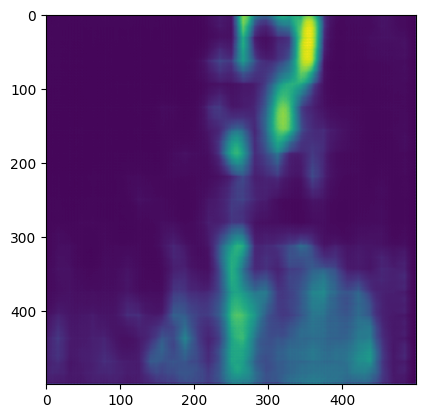

In [ ]:
output_path = './pi_prediction/output_image_01.mat'
loaded_data = sio.loadmat(output_path)
img = loaded_data['output']
plt.imshow(img, cmap='viridis')